# SERL Mock Data — Quick Overview

A concise walkthrough of the generated mock dataset: smart meter half-hourly data and contextual tables.
See [docs/04_metadata.md](../docs/04_metadata.md) for full column descriptions.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore")

# Resolve project root robustly whether CWD is notebooks/ or project root
_cwd = Path().resolve()
ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATA_DIR = ROOT / "data" / "mock"
HH_DIR = DATA_DIR / "serl_smart_meter_hh_edition08"

assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"
print("Root:", ROOT)
print("Data dir:", DATA_DIR)


Root: C:\Users\matte\projects_python\serl-mock
Data dir: C:\Users\matte\projects_python\serl-mock\data\mock


## 1. Dataset Inventory


In [2]:
# Flat CSV files
flat_files = [f for f in DATA_DIR.glob("*.csv")]
# HH monthly files
hh_files = sorted(HH_DIR.glob("*.csv"))

rows = []
for f in sorted(flat_files):
    df = pd.read_csv(f, encoding="latin-1")
    rows.append({"file": f.name, "rows": df.shape[0], "columns": df.shape[1]})
rows.append({"file": "--- half-hourly files ---", "rows": "", "columns": ""})
for f in hh_files:
    df = pd.read_csv(f, usecols=["PUPRN"])
    rows.append({"file": f.name, "rows": len(df), "columns": "17"})

pd.DataFrame(rows).to_string(index=False)


'                                           file   rows columns\n                          bst_dates_to_2030.csv     26       3\nElec_2023_list_of_exporter_puprns_edition08.csv      6       1\n                         epc_data_edition08.csv    100      84\n                               puprn_master.csv    100       1\n  serl_follow_up_survey_2023_data_edition08.csv    100       8\n    serl_participant_summary_data_edition08.csv    100       3\n                 serl_survey_data_edition08.csv    100      16\n                      --- half-hourly files ---               \n         serl_half_hourly_2019_01_edition08.csv 148800      17\n         serl_half_hourly_2019_02_edition08.csv 134400      17\n         serl_half_hourly_2019_03_edition08.csv 148800      17\n         serl_half_hourly_2019_04_edition08.csv 144000      17\n         serl_half_hourly_2019_05_edition08.csv 148800      17\n         serl_half_hourly_2019_06_edition08.csv 144000      17\n         serl_half_hourly_2019_07_editi

## 2. Half-Hourly Smart Meter — Sample & Stats


In [3]:
hh_jan = pd.read_csv(HH_DIR / "serl_half_hourly_2019_01_edition08.csv")
hh_jan["dt"] = pd.to_datetime(hh_jan["Read_date_time_UTC"].str.rstrip("Z"))

print(f"January file: {hh_jan.shape[0]:,} rows × {hh_jan.shape[1]} columns")
print(f"Households: {hh_jan['PUPRN'].nunique()}")
print(f"Date range: {hh_jan['dt'].min()}  →  {hh_jan['dt'].max()}\n")

cols = ["Elec_act_imp_hh_Wh", "Gas_hh_Wh"]
hh_jan[cols].describe().round(1)


January file: 148,800 rows × 18 columns
Households: 100
Date range: 2019-01-01 00:00:00  →  2019-01-31 23:30:00



,Elec_act_imp_hh_Wh,Gas_hh_Wh
count,148800.0,148800.0
mean,239.0,2339.8
std,248.9,1813.6
min,0.0,0.0
25%,97.0,1120.0
50%,178.0,2097.0
75%,306.0,3274.0
max,2786.0,14711.0


## 3. Time Series — One Week for Three Households


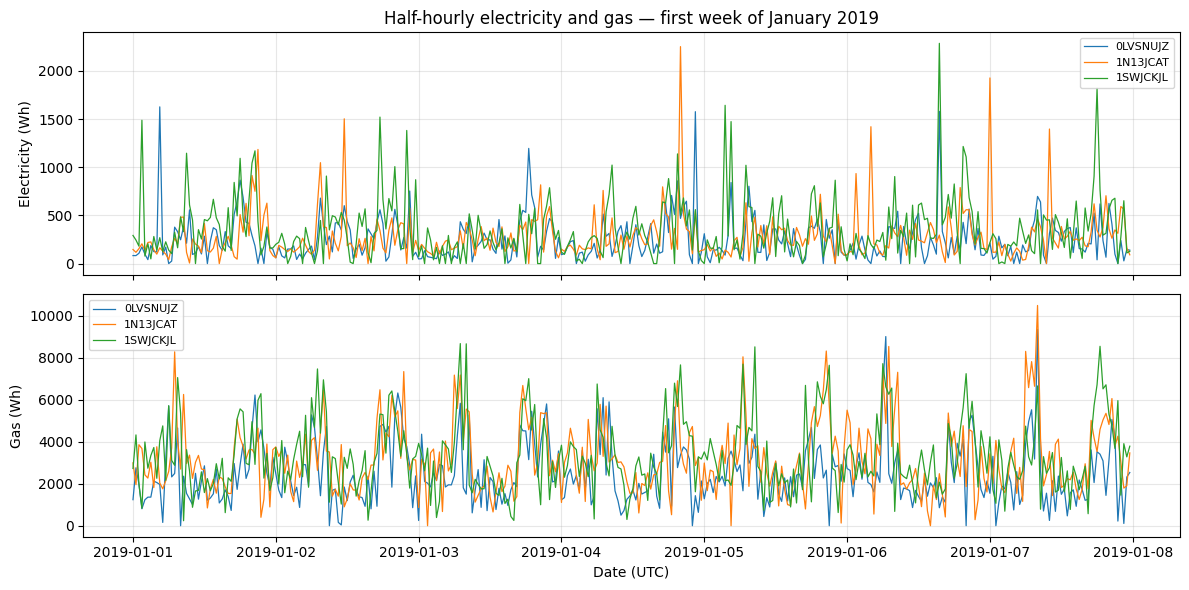

In [4]:
# Pick 3 PUPRNs that have gas (Gas_hh_Wh > 0 in January)
gas_households = (
    hh_jan.groupby("PUPRN")["Gas_hh_Wh"].sum()
    .loc[lambda s: s > 0]
    .index.tolist()
)
sample_puprns = gas_households[:3]

# One week: 7 days × 48 HH periods = 336 rows per household
week = hh_jan[
    (hh_jan["PUPRN"].isin(sample_puprns)) &
    (hh_jan["dt"] < hh_jan["dt"].min() + pd.Timedelta(days=7))
].sort_values(["PUPRN", "dt"])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for puprn in sample_puprns:
    sub = week[week["PUPRN"] == puprn]
    axes[0].plot(sub["dt"], sub["Elec_act_imp_hh_Wh"], label=puprn, linewidth=0.9)
    axes[1].plot(sub["dt"], sub["Gas_hh_Wh"], label=puprn, linewidth=0.9)

axes[0].set_ylabel("Electricity (Wh)")
axes[1].set_ylabel("Gas (Wh)")
axes[1].set_xlabel("Date (UTC)")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
axes[0].set_title("Half-hourly electricity and gas — first week of January 2019")
fig.tight_layout()
plt.show()


## 4. Seasonal Pattern — January vs July


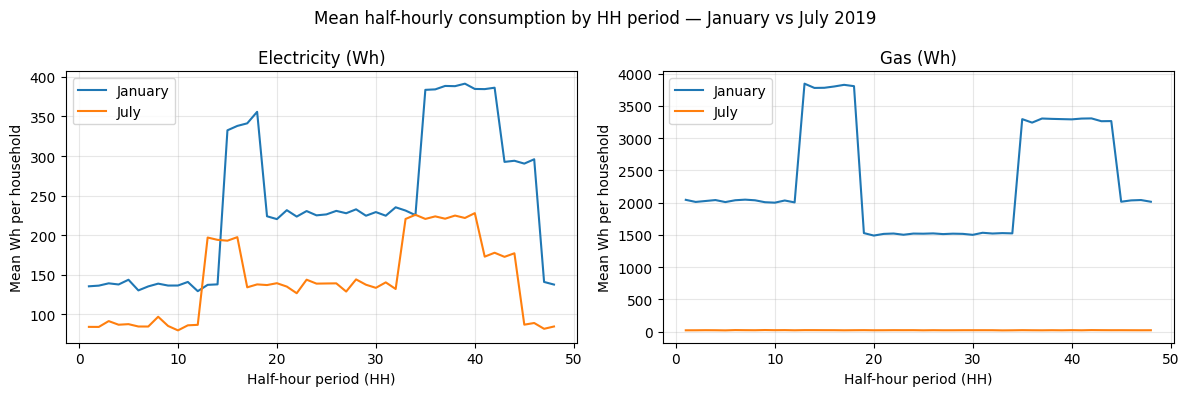

Electricity (Wh): Jan daily mean = 11470 Wh  |  Jul daily mean = 6842 Wh
Gas (Wh): Jan daily mean = 112306 Wh  |  Jul daily mean = 1054 Wh


In [5]:
hh_jul = pd.read_csv(HH_DIR / "serl_half_hourly_2019_07_edition08.csv")

seasonal = {}
for label, df in [("January", hh_jan), ("July", hh_jul)]:
    seasonal[label] = (
        df.groupby("HH")[["Elec_act_imp_hh_Wh", "Gas_hh_Wh"]]
        .mean()
        .rename(columns={"Elec_act_imp_hh_Wh": "Electricity (Wh)", "Gas_hh_Wh": "Gas (Wh)"})
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Electricity (Wh)", "Gas (Wh)"]):
    for label, df in seasonal.items():
        ax.plot(df.index, df[col], label=label)
    ax.set_title(col)
    ax.set_xlabel("Half-hour period (HH)")
    ax.set_ylabel("Mean Wh per household")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("Mean half-hourly consumption by HH period — January vs July 2019")
fig.tight_layout()
plt.show()

for col in ["Electricity (Wh)", "Gas (Wh)"]:
    print(f"{col}: Jan daily mean = {seasonal['January'][col].sum():.0f} Wh  |  "
          f"Jul daily mean = {seasonal['July'][col].sum():.0f} Wh")


## 5. Annual Daily Demand Profile (all 12 months)


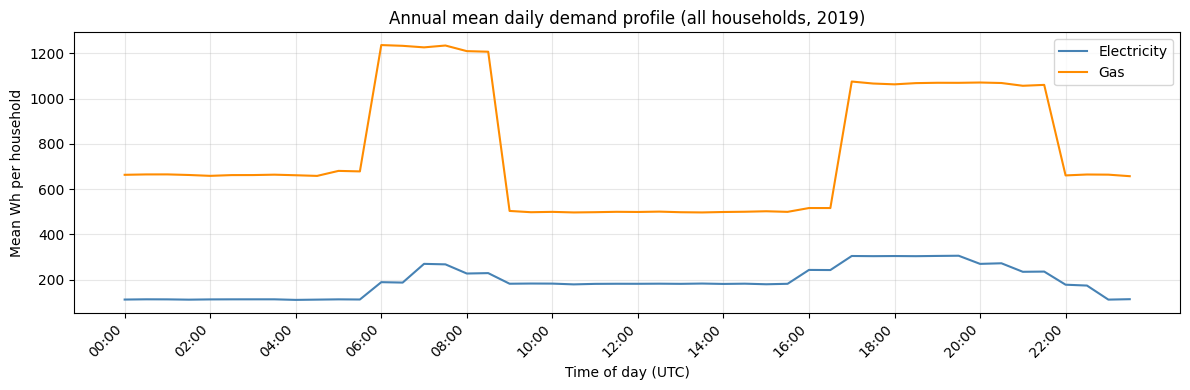

In [6]:
chunks = []
for f in sorted(HH_DIR.glob("*.csv")):
    chunks.append(pd.read_csv(f, usecols=["HH", "Elec_act_imp_hh_Wh", "Gas_hh_Wh"]))
hh_all = pd.concat(chunks, ignore_index=True)

profile = hh_all.groupby("HH")[["Elec_act_imp_hh_Wh", "Gas_hh_Wh"]].mean()
# x-axis: HH period 1–48 → hour label (UTC)
xticks = list(range(1, 49, 4))
xlabels = [f"{(hh - 1) // 2:02d}:{('30' if hh % 2 == 0 else '00')}" for hh in xticks]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(profile.index, profile["Elec_act_imp_hh_Wh"], label="Electricity", color="steelblue")
ax.plot(profile.index, profile["Gas_hh_Wh"], label="Gas", color="darkorange")
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=45, ha="right")
ax.set_xlabel("Time of day (UTC)")
ax.set_ylabel("Mean Wh per household")
ax.set_title("Annual mean daily demand profile (all households, 2019)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 6. EPC Overview


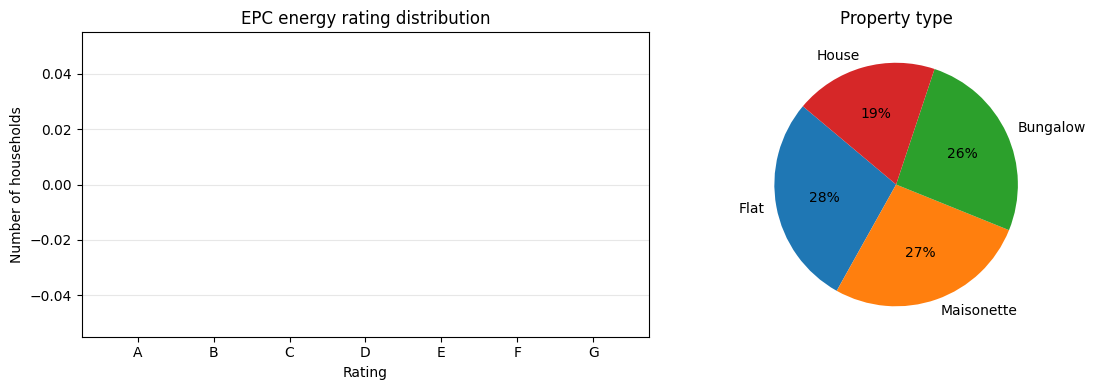

Mean current energy efficiency score: 60.9
Mean floor area: 158.7 m²


In [7]:
epc = pd.read_csv(DATA_DIR / "epc_data_edition08.csv")

RATING_ORDER = list("ABCDEFG")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Energy rating distribution
rating_counts = (
    epc["currentEnergyRating"]
    .value_counts()
    .reindex(RATING_ORDER, fill_value=0)
)
axes[0].bar(rating_counts.index, rating_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("EPC energy rating distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of households")
axes[0].grid(axis="y", alpha=0.3)

# Property type distribution
prop_counts = epc["PROPERTY_TYPE"].value_counts()
axes[1].pie(
    prop_counts.values,
    labels=prop_counts.index,
    autopct="%1.0f%%",
    startangle=140,
)
axes[1].set_title("Property type")

fig.tight_layout()
plt.show()

print(f"Mean current energy efficiency score: {epc['CURRENT_ENERGY_EFFICIENCY'].mean():.1f}")
print(f"Mean floor area: {epc['totalFloorArea'].mean():.1f} m²")


## 7. Participant Summary — Region & IMD Quintile


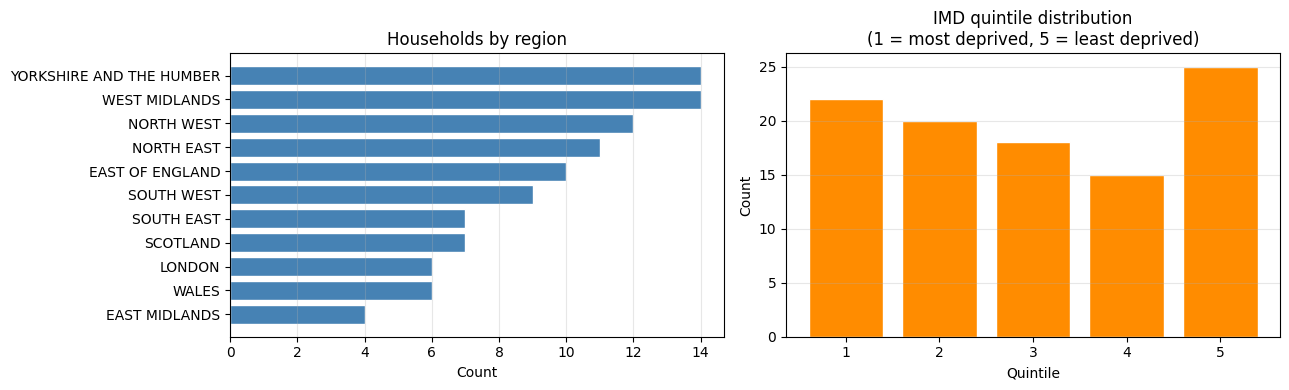

Region
WEST MIDLANDS               14
YORKSHIRE AND THE HUMBER    14
NORTH WEST                  12
NORTH EAST                  11
EAST OF ENGLAND             10
SOUTH WEST                   9
SCOTLAND                     7
SOUTH EAST                   7
LONDON                       6
WALES                        6
EAST MIDLANDS                4


In [8]:
summ = pd.read_csv(DATA_DIR / "serl_participant_summary_data_edition08.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Region counts
region_counts = summ["Region"].value_counts().sort_values()
axes[0].barh(region_counts.index, region_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Households by region")
axes[0].set_xlabel("Count")
axes[0].grid(axis="x", alpha=0.3)

# IMD quintile distribution
imd_counts = summ["IMD_quintile"].value_counts().sort_index()
axes[1].bar(imd_counts.index.astype(str), imd_counts.values, color="darkorange", edgecolor="white")
axes[1].set_title("IMD quintile distribution\n(1 = most deprived, 5 = least deprived)")
axes[1].set_xlabel("Quintile")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

print(summ.groupby("Region").size().sort_values(ascending=False).to_string())
